In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
import recharge_funcs as rf

In [2]:
models = ["GFDL-ESM4", "IPSL-CM6A-LR", "MPI-ESM1-2-HR", "MRI-ESM2-0", "UKESM1-0-LL"]
scenarios = ["historical", "ssp370", "ssp585"]

#station coordinates
station_locations = pd.read_csv("mHM_eval_stations.csv")
#Boundaries data
be_shp = gpd.read_file(r"W:/VUB/_main_research/mHM/mhm_belgium/be_shp/be.shp")

#rivers
# rivers_shp = gpd.read_file(r"W:/VUB/_main_research/data/shapefiles/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu_shp/hydroRivers_BE.shp")

#eval stations pickle path
base_data_dir = r"D:\VUB\_data\_isimip_3b\isimip_mhm_scenario_inputs"

#### Read model scenarios and compute ensemble mean

In [3]:
#read scenarios data
def read_scenario_data(models, scenarios, var, base_data_dir):
    model_scenario_data = {}
    for model in models:
        for scen in scenarios:
            file_path = os.path.join(base_data_dir, f"{model}/{scen}/{var}.nc")
            if os.path.exists(file_path):
                ds = xr.open_dataset(file_path)
                ds_BE = rf.clip_to_region(be_shp, ds)

                ds_actual = ds_BE[var].where(ds_BE[var].var(dim="time") > 0.0001)

                da = ds_actual.to_dataset(name=var)
                model_scenario_data[f"{model}_{scen}_{var}"] = da

    return model_scenario_data

#compute ensemble mean per scenario
def compute_ensemble_mean(model_scenario_data, var):
    ensemble_mean_proportions = {}
    for scen in scenarios:
        scen_datasets = [ds[var] for key, ds in model_scenario_data.items() if scen in key and var in key]
        if scen_datasets:
            combined = xr.concat(scen_datasets, dim="model") #concatenate along a new 'model' dimension
            ensemble_mean = combined.mean(dim="model") #compute mean across models
            ensemble_mean_proportions[scen] = ensemble_mean
    return ensemble_mean_proportions

In [4]:
#example usage
variables= ["pre", 'pet', 'tavg']
#dict of processed data for all variables, models, and scenarios
var_dict = {}
for var in variables:
    var_data = read_scenario_data(models, scenarios, var, base_data_dir)
    var_ensemble_mean = compute_ensemble_mean(var_data, var)
    var_dict[var] = var_ensemble_mean

### Changes in variable between scenarios

In [5]:

#function to compute mean monthly values across years and gridcells for each scenario
def compute_monthly_climatology(var_dict, var, scenarios, historical_slice, future_slice):
    monthly_clim = {}
    for scen in scenarios:
        if scen=='historical':
            var_data = var_dict[var][scen].sel(time=historical_slice)
        else:
            var_data = var_dict[var][scen].sel(time=future_slice)
        
        #compute mean monthly values across years
        #for temperature we compute mean monthly values across years, 
        # for PET and pre we first aggregate daily values to monthly sums, then compute mean across years
        if var == 'tavg':
            var_monthly = var_data.groupby("time.month").mean(dim="time")
        else:
            var_monthly = var_data.resample(time="ME").sum().groupby("time.month").mean(dim="time")
            var_monthly = var_monthly.where(var_monthly != 0)
        
        var_monthly_df = var_monthly.mean(dim=["lat", "lon"]).to_dataframe().reset_index()
        var_monthly_df['month'] = var_monthly_df['month'].astype(int)
        #map month numbers to month names
        month_mapping = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
        var_monthly_df['month'] = var_monthly_df['month'].map(month_mapping)
        #select only month and variable columns
        var_monthly_df = var_monthly_df[['month', var]]
        #set month as index
        var_monthly_df.set_index('month', inplace=True)

        monthly_clim[scen] = var_monthly_df
    return monthly_clim

In [6]:

#start and end years for historical and future scenarios
historical_slice = slice("1971", "2000")
future_slice = slice("2071", "2100")
var_dict = var_dict
variables = ["pre", 'pet', 'tavg']

all_vars_monthly_clim = {}
for var in variables:
    var_monthly_clim = compute_monthly_climatology(var_dict, var, scenarios, historical_slice, future_slice)
    print(f"Monthly climatology for {var}:")
    all_vars_monthly_clim[var] = var_monthly_clim

Monthly climatology for pre:
Monthly climatology for pet:
Monthly climatology for tavg:


### Plots

In [7]:
#rename scenarios in dict to Historical, SSP3-7.0, SSP5-8.5
scenario_mapping = {
    "historical": "Historical",
    "ssp370": "SSP3-7.0",
    "ssp585": "SSP5-8.5"
}
all_vars_monthly_clim_renamed = {}
for var, scen_dict in all_vars_monthly_clim.items():
    renamed_dict = {scenario_mapping[scen]: df for scen, df in scen_dict.items()}
    all_vars_monthly_clim_renamed[var] = renamed_dict

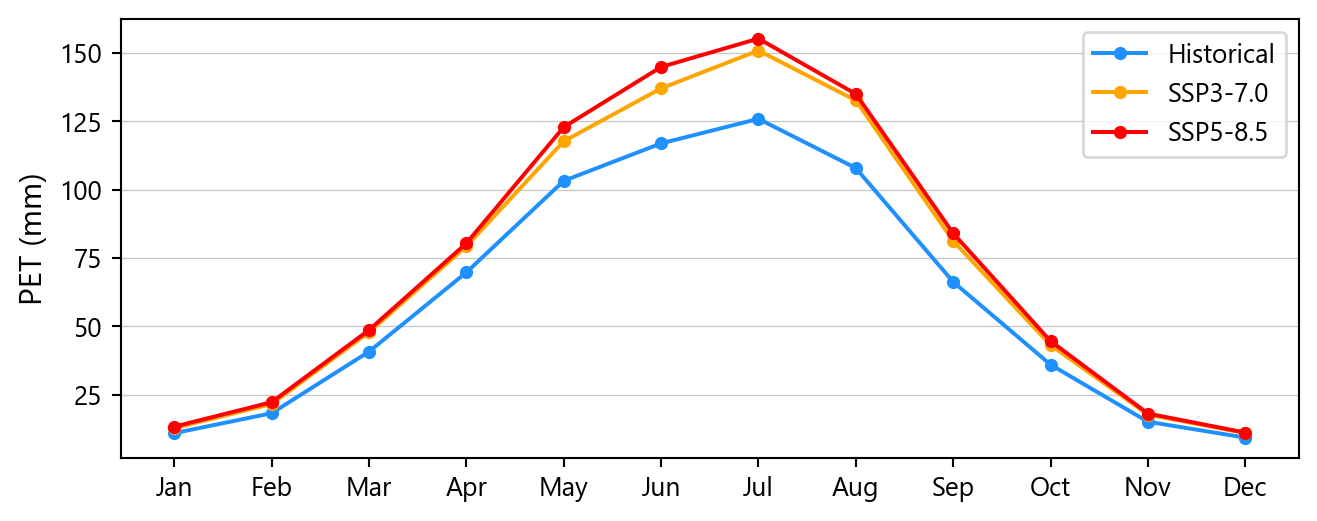

In [8]:
scenarios_renamed = [scenario_mapping[scen] for scen in scenarios]

#plot PET for all scenarios
plt.figure(figsize=(8, 3.0), dpi=190)
colors = ['dodgerblue', 'orange', 'red']  # Define colors for each scenario
for scen in scenarios_renamed:
    plt.plot(all_vars_monthly_clim_renamed['pet'][scen]['pet'], label=scen, 
             color=colors[scenarios_renamed.index(scen)], marker='o', markersize=4)
plt.ylabel("PET (mm)", fontsize=12)
plt.grid(axis='y', alpha=0.7, lw=0.5)
plt.legend(fontsize=10)

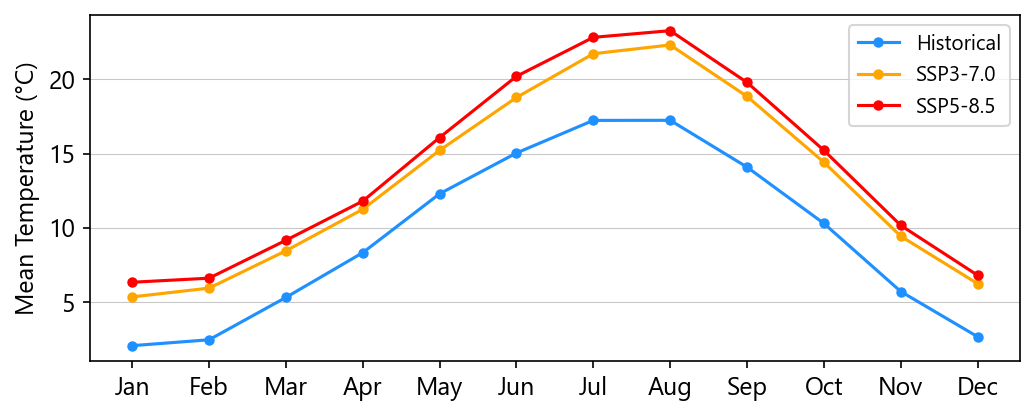

In [9]:
#plot tavg for all scenarios
plt.figure(figsize=(8, 3), dpi=150)

colors = ['dodgerblue', 'orange', 'red']  # Define colors for each scenario
for scen in scenarios_renamed:
    plt.plot(all_vars_monthly_clim_renamed['tavg'][scen]['tavg'], label=scen, 
             color=colors[scenarios_renamed.index(scen)], marker='o', markersize=4)
plt.ylabel("Mean Temperature (°C)", fontsize=12)
plt.grid(axis='y', alpha=0.7, lw=0.5)
plt.legend(fontsize=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

In [10]:
mon_change = (all_vars_monthly_clim_renamed['pet']['SSP5-8.5'] -all_vars_monthly_clim_renamed['pet']['Historical'])

seasons = {
    'Winter': ['Dec', 'Jan', 'Feb'],
    'Spring': ['Mar', 'Apr', 'May'],
    'Summer': ['Jun', 'Jul', 'Aug'],
    'Autumn': ['Sep', 'Oct', 'Nov']
}

seasonal_changes = {}
for season, months in seasons.items():
    seasonal_changes[season] = mon_change.loc[months].mean()

In [11]:
all_vars_monthly_clim_renamed['pet']['SSP5-8.5']

,pet
month,
Jan,13.290756
Feb,22.256544
Mar,48.645267
Apr,80.394306
May,122.889341
Jun,144.901169
Jul,155.286850
Aug,135.017099
Sep,84.026980


In [12]:
seasonal_changes

{'Winter': pet    2.753868
 dtype: float64,
 'Spring': pet    12.734996
 dtype: float64,
 'Summer': pet    28.152942
 dtype: float64,
 'Autumn': pet    9.794648
 dtype: float64}

#### Water Availability

In [13]:
### Calculate pre-PET for all scenarios
pre_pet_clim = {}
for scen in scenarios_renamed:
    pre_clim = all_vars_monthly_clim_renamed['pre'][scen]
    pet_clim = all_vars_monthly_clim_renamed['pet'][scen]
    pre_pet = pre_clim['pre'] - pet_clim['pet']
    pre_pet.columns = ['month','wb']
    pre_pet_clim[scen] = pre_pet

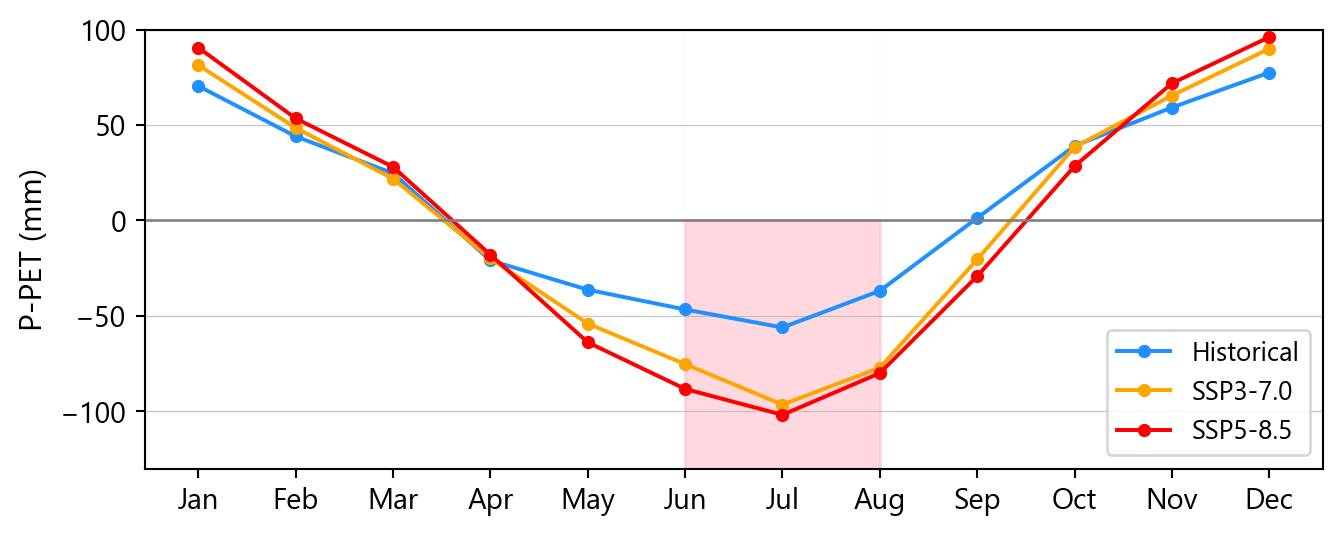

In [14]:
#plot p-pet for all scenarios
plt.figure(figsize=(8, 3), dpi=190)
colors = ['dodgerblue', 'orange', 'red']  # Define colors for each scenario
for scen in scenarios_renamed:
    plt.plot(pre_pet_clim[scen], label=scen, color=colors[scenarios_renamed.index(scen)], marker='o', markersize=4)
plt.axhline(0, color='gray', lw=1)  # Add a horizontal line at y=0 for reference

#vertical lines from month names June to August with shaded area for summer season
plt.axvline(x='Jun', color='gray', lw=0.01)
plt.axvline(x='Aug', color='gray', lw=0.01)
plt.fill_betweenx(y=[-130, 0], x1='Jun', x2='Aug', color='pink', alpha=0.6)
plt.ylim(-130, 100)
plt.grid(axis='y', alpha=0.7, lw=0.5)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11);
plt.ylabel("P-PET (mm)", fontsize=12)
plt.legend(loc='lower right', fontsize=10, ncol=1)

In [15]:
pre_pet_clim['SSP5-8.5'] - pre_pet_clim['Historical']

#group by season and compute mean pre-pet for each season and scenario
pre_pet_clim_seasonal = {}
for scen in scenarios_renamed:
    pre_pet_clim_seasonal[scen] = {}
    for season, months in seasons.items():
        pre_pet_clim_seasonal[scen][season] = pre_pet_clim[scen].loc[months].mean()

In [16]:
pre_pet_clim

{'Historical': month
 Jan    70.450164
 Feb    44.053887
 Mar    24.684521
 Apr   -20.950322
 May   -36.296925
 Jun   -46.650111
 Jul   -56.069299
 Aug   -36.900448
 Sep     1.289918
 Oct    39.044591
 Nov    59.178841
 Dec    77.493753
 dtype: float64,
 'SSP3-7.0': month
 Jan    81.415268
 Feb    48.510050
 Mar    21.848443
 Apr   -19.897893
 May   -54.062354
 Jun   -75.293141
 Jul   -96.491421
 Aug   -77.169906
 Sep   -20.446836
 Oct    38.480269
 Nov    65.453994
 Dec    89.978301
 dtype: float64,
 'SSP5-8.5': month
 Jan     90.559334
 Feb     53.479517
 Mar     28.052624
 Apr    -17.954891
 May    -63.871279
 Jun    -88.295563
 Jul   -101.871841
 Aug    -79.984037
 Sep    -29.239314
 Oct     28.425872
 Nov     71.854895
 Dec     96.092749
 dtype: float64}

In [17]:
pre_pet_clim_seasonal

{'Historical': {'Winter': 63.99926796283852,
  'Spring': -10.854241901110159,
  'Summer': -46.53995247634719,
  'Autumn': 33.171116754292534},
 'SSP3-7.0': {'Winter': 73.30120648372177,
  'Spring': -17.370601151530803,
  'Summer': -82.98482276842005,
  'Autumn': 27.82914244112391},
 'SSP5-8.5': {'Winter': 80.04386679605672,
  'Spring': -17.924515153739936,
  'Summer': -90.05048021350729,
  'Autumn': 23.68048439800076}}